# Comparison between Size-Frequency Distributions of Lunar Impact Craters and Near-Earth Objects
### Antara Mazumdar, Kai-Xing Yue

## Introduction

Asteroids have been the cause of major extinctions occurring millions of years ago on Earth, but due to erosion and tectonic movement, the impact craters left behind were erased before we were able to study them (Huber et al. 2023; Salotti 2022). Craters on the Moon provide a thorough record of asteroid impacts which are useful for scientific analysis. In this paper, we compare the size-frequency distribution (SFD) of lunar impact craters to the size-frequency distribution of near-Earth objects (NEOs) and discuss its implications on the formation of craters on the Moon. We can use the lunar crater SFDs to determine if the impacts are from NEOs or from the more distant asteroid belts of the solar system to understand the risk NEOs pose to civilization on earth (Salotti 2022).

A similar study comparing the SFDs of a time averaged projectile population derived from NEO and lunar crater data was conducted in 2002 and found a strong correlation between the size and frequency of NEO and lunar craters (Werner 2002). However, recent work utilizing modern technology has significantly expanded the range of crater sizes identified and achieved a more complete catalog of both lunar and NEO databases (Robbins 2018). In this study, we use the Robbins Lunar Crater database published in 2018 which compiled data from many different instruments and is considered 93.8% complete for craters ≥ 2km (Robbins 2018). Since current databases for NEOs are incomplete and not fully cataloged, we also draw our NEO SFD from the New Orbital Distribution Model for Near Earth Objects (NEOMOD) which generates a debiased size distribution for NEOs within a certain size range based on observations of the Catalina Sky Survey (Nesvorny et al. 2023).

## Methods
To answer our question, we needed data for both lunar craters, and NEOs. For craters, we chose to construct our lunar crater SFD from the Robbins Database, a reputable, well-cited paper containing complete information on craters with diameter ≥ 1-2km (Robbins 2018). We created our SFD from NEO data collected by running the fortran program of an observational data based simulator NEOMOD (Nesvorny et al 2023). We modified the parameters to generate data for 1,000,000 asteroids, with diameter ranging from 0.05 km to 100 km (maximum permitted by the program).


```
# In neomod3.par, change the number of results to 1000000.
# Fortran code (Note: must be run on a device with fortran installed)
gfortran -o neomod3_simulator neomod3_simulator.f  
./neomod3_simulator < neomod3.par > output_file.txt
```



Before conducting our analysis, we checked for missing data for both datasets. We found 38 out of 1,296,758 (> 0.01%) entries in the Robbins database were missing values and simply removed them from our dataset because we did not have sufficient data to reasonably extrapolate the value and the number was insignificant compared to the total. Since our NEO data is simulated, we did not expect or find any missing values. We also performed several other data cleaning steps including ensuring a valid range for longitude (within 0 - 360 degrees), latitude (between -90 to 90 degrees), and diameter values (non-negative) extracted. We found that both data sets did not include data outside of bounds.

In [ ]:
# Python libraries needed to run the code
# Run this cell before running any other code cell
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import random
from scipy.stats import beta
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Data loading and checking step
# May take a while to run because of the sanity checks

# Replace the file paths here with your own
robbins_data = pd.read_csv('/content/drive/MyDrive/AstroStats Paper/lunar_crater_database_robbins_2018.csv')
neo_data = pd.read_csv('/content/drive/MyDrive/AstroStats Paper/output_million.txt', sep='\\s+')

# Check for missing values for Robbins
missing_values = robbins_data.isnull().sum()

for column in missing_values[missing_values > 0].index:
    missing_indices = robbins_data[robbins_data[column].isnull()].index
print(f"Indexes with missing values in columns: {list(missing_indices)}")

# Drop missing values
robbins_data = robbins_data.drop(missing_indices)
print(len(robbins_data))

# Check for missing values for NEO
missing_values2 = neo_data.isnull().sum()

missing_indices2 = []
for column in missing_values2[missing_values2 > 0].index:
    missing_indices2 = neo_data[neo_data[column].isnull()].index
print(f"Indexes with missing values in columns: {list(missing_indices2)}")
neo_data = neo_data.drop(missing_indices2)
print(len(neo_data))

# Other sanity checks for Robbins
for index, row in robbins_data.iterrows():
    if row['LON_CIRC_IMG'] > 360 or row['LON_CIRC_IMG'] < 0 : # checks longitude is within 0-360 range
        print(row['LON_CIRC_IMG'], 'is out of bounds')
    if row['LAT_CIRC_IMG'] > 90 or row['LAT_CIRC_IMG'] < -90 :
        print(row['LAT_CIRC_IMG'], 'is out of bounds')
    if row['DIAM_CIRC_SD_IMG'] < 0 :
        print(row['DIAM_CIRC_SD_IMG'], 'is out of bounds')

Indexes with missing values in columns: [9487, 138100, 139374, 156954, 243143, 247775, 275603, 330339, 333927, 336158, 341478, 348769, 373148, 380703, 385242, 395970, 488982, 522711, 525999, 534709, 542930, 545039, 647653, 680639, 680723, 693928, 700709, 701058, 705095, 705819, 825312, 832235, 835582, 855017, 1083694, 1223125, 1263215, 1280490]
1296758
Indexes with missing values in columns: []
999999


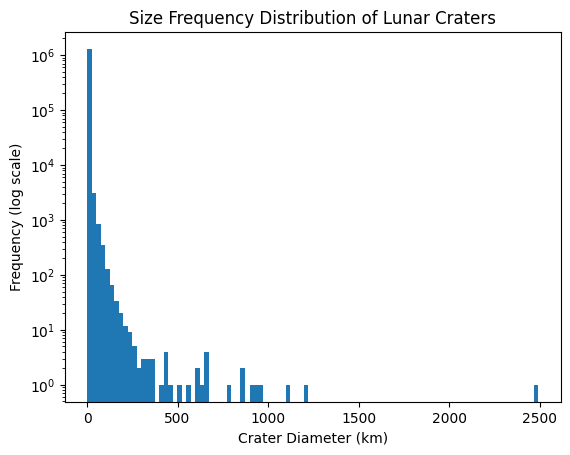

Fig 1. Size frequency distribution for 1,296,758 craters on the moon obtained from the Robbins database, with crater diameter (km) on the y-axis and a log scale for the frequency of the diameter bin on the x-axis.

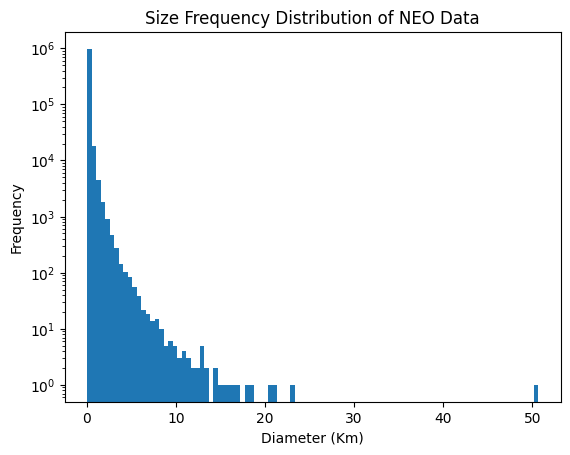

Fig 2. Size frequency distribution of 1,000,000 NEOs generated by NEOMOD simulator, with diameter (km) as the y-axis and a log scale for the frequency of the diameter bin on the x axis.

In [ ]:
# Code to plot the SFDs above
# Plot crater SFD
plt.hist(robbins_data['DIAM_CIRC_IMG'], bins=100)
plt.xlabel('Crater Diameter (km)')
plt.ylabel('Frequency (log scale)')
plt.title('Size Frequency Distribution of Lunar Craters')
plt.yscale('log')
plt.show()

# Plot NEO Data SFD
plt.hist(neo_data.iloc[:, 4], bins=100)
plt.xlabel('Diameter (Km)')
plt.ylabel('Frequency (log scale)')
plt.title('Size Frequency Distribution of Near Earth Objects')
plt.yscale('log')
plt.show()

In our analysis, we assume the face of the asteroid impacting the Moon as having uniform diameter and use diameter as the variable defining the size of the crater and asteroid. However, the impacts of these assumptions should be negligible as the Robbins database utilizes a Taubin fit to model a crater as a circle which has a small total mean square error of about $ 7.5 \cdot 10^{-6} km $ (Al-Sharadqah & Chernov 2009; Robbins 2018).

Our aim was to compare the possible impact craters that NEOs would make on the Moon with the existing lunar craters to extrapolate whether the lunar craters match the NEO profile. To conduct an analysis independent of sample size, we normalized both the Robbins database SFD (Fig 3.) as well as the simulated craters SFD by dividing by their respective sizes. This provided a visual method to compare the SFDs because they represent a fraction of the total.

In [ ]:
# Create the normalized SFD of the lunar crater data
robbins_diameters = robbins_data['DIAM_CIRC_IMG']
num_bins = 100
bin_edges = np.linspace(0, max(robbins_data['DIAM_CIRC_IMG']), num_bins + 1)
robbins_count, _ = np.histogram(robbins_diameters, bins=bin_edges)
rel_freq_robbins = robbins_count / len(robbins_diameters)
bin_centers1 = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.bar(bin_centers1, rel_freq_robbins, width=bin_edges[1]-bin_edges[0])
plt.xlabel('Crater Diameter (km)')
plt.ylabel('Relative Frequency (per bin)')
plt.title('Normalized Size Frequency Distribution (Robbins Data)')
plt.yscale('log')
plt.show()

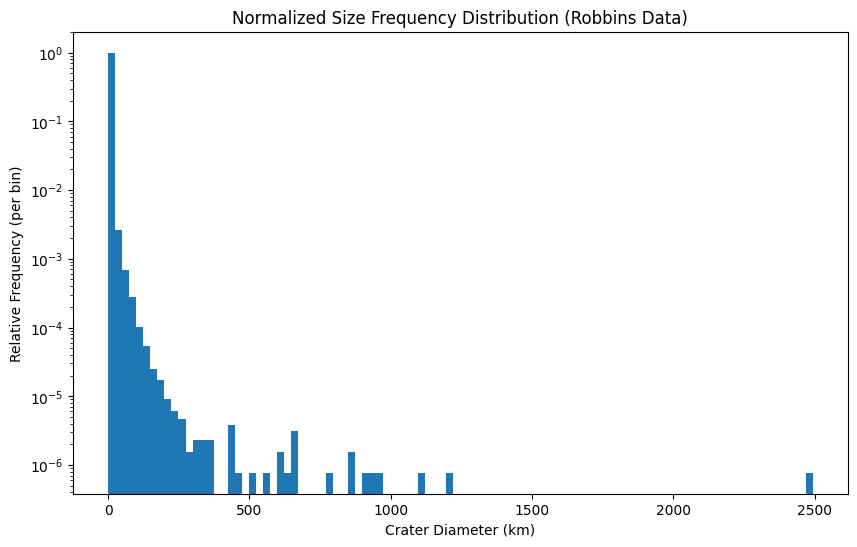

Fig 3. Size frequency distribution of the craters in the Robbins database normalized by the sample size

To simulate the potential diameters of impact craters made by NEOs, we used the following crater scaling law (Schmidt & Housen 1987):

$ D_t = 1.16 \cdot (\frac{δ}{ρ})^{\frac{1}{3}} \cdot {D_p}^ {0.78} \cdot (v \cdot sin(a) ^{0.43}) \cdot g^{-0.22} \qquad \qquad \qquad ... (1) $

where $ D_t $ is the transient crater diameter, $D_p$ is the projectile diameter, ρ and δ are densities of target and projectile materials, v is the impact velocity, α is the impact angle, and g is the gravitational acceleration on the Moon. For craters larger than 1-2km, the transient crater derived by this equation is roughly equal to the final diameter of the crater (Ivanov 2001; Schmidt & Housen 1987).

We used a skewed beta distribution (Fig. 4.) to model impact velocities in the range of 3.1 to 70 km/s with a mean impact velocity of 17.4 km/s, referencing these values from the impact velocity distribution developed by Yue et al. (2013). For the impact angles, we generated a beta distribution (Fig. 5.) over the range 0-90 degrees with more than 50% of the values falling in the 30-60 range, referencing these values from Davison & Collins (2022). There is not enough data on the different materials that make up NEOs to make a distribution of densities, so we instead used the value $ 2.7 g/cm^3 $ which is the average density for silicon, one of the most common asteroid compositions (Britt et al.; Ivanov et al. 2002). This is an abstraction of the actual distribution of densities which varies greatly as different asteroids are composed of many different materials including carbon and nickel-iron. However, we do not expect this abstraction to have a significant impact on our results because the bulk densities of asteroids across different compositions vary on a much smaller magnitude ($ 1 g/cm^3 - 3.5 g/cm^3 $) than other factors like impact velocity and simulated NEO diameters (Britt et al.; Ivanov et al. 2002).


In [ ]:
# Generating the velocity frequency distribution

# Parameters
a, b = 2, 8
samples = beta.rvs(a, b, size=len(neo_data))

# Compute statistics
mean_val = np.mean(samples)
median_val = np.median(samples)
rms_val = np.sqrt(np.mean(samples**2))

# Normalize to match target mean and RMS from Yue, 2013
target_mean = 17.4
target_rms = 18.8
scaled_samples = samples * target_rms / rms_val
scaled_samples += target_mean - np.mean(scaled_samples)
velocities = scaled_samples

plt.hist(velocities, bins=100)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Velocities')
plt.show()


# Generating the impact angles

a, b = 10, 10
samples = beta.rvs(a, b, size=len(neo_data))
angles = samples * 90

plt.hist(angles, bins=100)
plt.title('Frequency Distribution of Impact Angles')
plt.xlabel('Impact Angle (degrees)')
plt.ylabel('Number of Values')
plt.show()

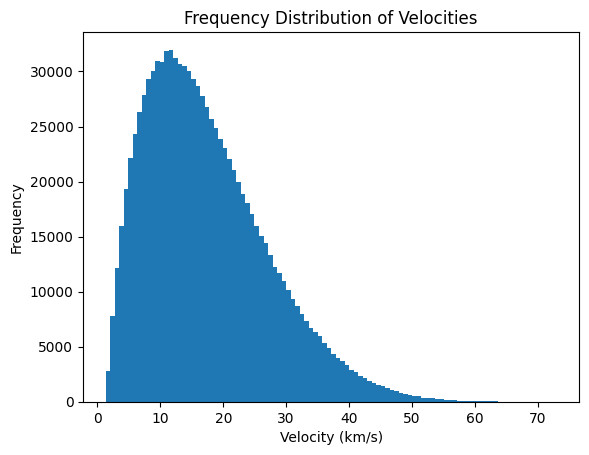

Fig 4. Beta distribution of NEO impact velocities, using mean value from Yue et. al, 2013

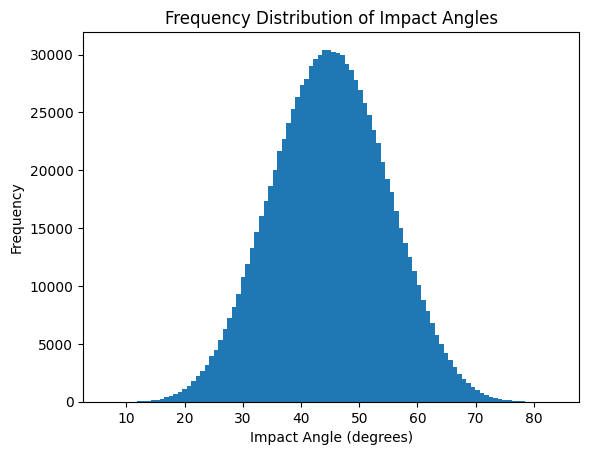

Fig 5. Distribution of impact angles of the NEOs

We then performed 10000 Monte Carlo simulations, sampling a random velocity and angle from our distributions, iterating through all the desired NEO diameters, and substituting the values into equation (1) to simulate the impact crater size. After simulation completion, we normalized the NEO crater distribution as well as the Robbins crater distribution to obtain sample-independent histograms (Fig. 6.) for ease of comparison since we are looking for overall shape and trends of the distributions rather than exact frequency values. To generate the error bars for our distribution, we took the standard deviation for each frequency bin over all 10000 runs of the simulation. We expect the size of the error bars to be large for craters ≥ 150km, since only in a few simulations do craters greater than that occur, and thus the mean for those bins is small and the standard deviation is large.

In [ ]:
# Monte Carlo Simulation of asteroid impacts
# Warning - takes a long time (>45min) to run if not on a supercomputer!

delta = 3.34  # g/cm³
g = 0.00162   # km/s²
rho = 2.5     # g/cm³

num_runs = 10000
num_bins = 100
num_samples = len(neo_data)

bin_edges = np.linspace(0, 800, num_bins + 1)
D_p_vals = neo_data.iloc[:, 4].values

all_counts = []
medians = []

for _ in range(num_runs):
    angle = np.random.choice(angles, size=num_samples)
    velocity = np.random.choice(velocities, size=num_samples)

    D_t = (1.16 * ((delta / rho) ** (1/3)) * (D_p_vals ** 0.78) *
           ((velocity * np.sin(np.deg2rad(angle))) ** 0.43) *
           (g ** -0.22))

    # Histogram counts
    counts, _ = np.histogram(D_t, bins=bin_edges)
    all_counts.append(counts)
    medians.append(np.median(D_t))

all_counts = np.array(all_counts)

# Mean and standard deviation per bin
mean_counts = np.mean(all_counts, axis=0)
std_counts = np.std(all_counts, axis=0)

# Normalize to relative frequencies
rel_freq_simulated = mean_counts / np.sum(mean_counts)
rel_freq_err = std_counts / np.sum(mean_counts)

# Bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, rel_freq_simulated, width=bin_edges[1] - bin_edges[0], color='blue', alpha=0.6)

# Overlay error bars
plt.errorbar(bin_centers, rel_freq_simulated, yerr=rel_freq_err, fmt='none', ecolor='red', alpha=0.6, capsize=3, label='Error Bar (±1σ)')

plt.xlabel('Simulated Crater Diameter (km)')
plt.ylabel('Average Relative Frequency (normalized)')
plt.title('Normalized Size Frequency Distribution of Simulated Lunar Craters with Error Bars')
plt.yscale('log')
plt.legend()
plt.show()

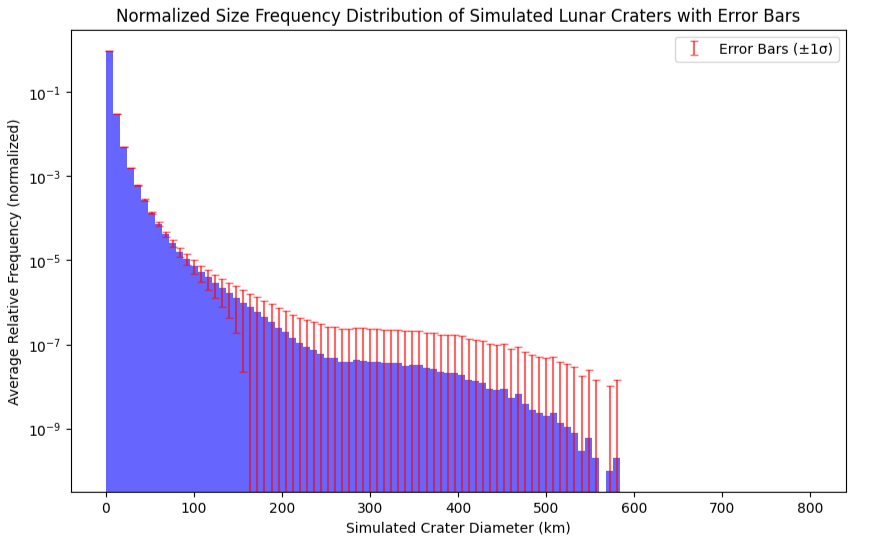

Fig 6. Normalized relative size frequency distribution graph for simulated craters with error bars in red.

In [ ]:
# This data is generated from the run of the code that generated the plot above
# Pasted here for convenience and reproducability of results
# Comment out if running the actual code!

rel_freq_simulated = [
9.62473086e-01, 2.98181355e-02, 4.91957052e-03, 1.57285897e-03,
6.11748312e-04, 2.72339472e-04, 1.34390234e-04, 7.32093732e-05,
4.24289424e-05, 2.55368255e-05, 1.61896162e-05, 1.07849108e-05,
7.48100748e-06, 5.30590531e-06, 3.96710397e-06, 2.94280294e-06,
2.22740223e-06, 1.69690170e-06, 1.29830130e-06, 9.92300992e-07,
7.62900763e-07, 5.85300585e-07, 4.40800441e-07, 3.36400336e-07,
2.48300248e-07, 1.95000195e-07, 1.40600141e-07, 1.10800111e-07,
8.78000878e-08, 7.25000725e-08, 5.95000595e-08, 4.71000471e-08,
4.83000483e-08, 3.87000387e-08, 3.75000375e-08, 4.22000422e-08,
4.14000414e-08, 3.94000394e-08, 3.77000377e-08, 3.55000355e-08,
3.60000360e-08, 3.57000357e-08, 3.16000316e-08, 3.28000328e-08,
3.18000318e-08, 2.74000274e-08, 2.60000260e-08, 2.23000223e-08,
2.16000216e-08, 2.14000214e-08, 1.90000190e-08, 1.42000142e-08,
1.39000139e-08, 1.21000121e-08, 8.80000880e-09, 8.40000840e-09,
8.90000890e-09, 5.50000550e-09, 6.60000660e-09, 3.80000380e-09,
2.80000280e-09, 2.40000240e-09, 2.00000200e-09, 2.30000230e-09,
1.40000140e-09, 1.10000110e-09, 8.00000800e-10, 3.00000300e-10,
6.00000600e-10, 2.00000200e-10, 0.00000000e+00, 1.00000100e-10,
2.00000200e-10, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00
]
rel_freq_robbins = [
9.71956044e-01, 2.01156738e-02, 3.91902834e-03, 1.46211683e-03,
7.58048969e-04, 4.93541546e-04, 3.35454020e-04, 2.35203393e-04,
1.72739541e-04, 1.08733372e-04, 9.56236746e-05, 7.63447079e-05,
6.01503759e-05, 3.31598226e-05, 2.62193946e-05, 2.62193946e-05,
2.00501253e-05, 1.46520147e-05, 1.23385387e-05, 1.00250627e-05,
6.94042799e-06, 6.94042799e-06, 1.00250627e-05, 3.08463466e-06,
7.71158666e-07, 3.08463466e-06, 3.85579333e-06, 2.31347600e-06,
2.31347600e-06, 3.85579333e-06, 0.00000000e+00, 1.54231733e-06,
7.71158666e-07, 2.31347600e-06, 0.00000000e+00, 0.00000000e+00,
7.71158666e-07, 7.71158666e-07, 0.00000000e+00, 7.71158666e-07,
3.08463466e-06, 7.71158666e-07, 0.00000000e+00, 0.00000000e+00,
1.54231733e-06, 7.71158666e-07, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
7.71158666e-07, 1.54231733e-06, 7.71158666e-07, 7.71158666e-07,
0.00000000e+00, 7.71158666e-07, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.71158666e-07,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 7.71158666e-07, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 7.71158666e-07, 0.00000000e+00,
7.71158666e-07, 0.00000000e+00, 0.00000000e+00, 7.71158666e-07,
0.00000000e+00, 1.54231733e-06, 1.54231733e-06, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.71158666e-07
]

In [ ]:
# Comparing the SFDs
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(bin_centers, rel_freq_simulated,
       width=bin_edges[1] - bin_edges[0],
       color='blue', alpha=0.6, label='Simulated')

ax.bar(bin_centers1, rel_freq_robbins,
       width=bin_edges[1] - bin_edges[0],
       color='red', alpha=0.6, label='Robbins')

ax.set_xlabel('Crater Diameter (km)')
ax.set_ylabel('Relative Frequency (log scale)')
ax.set_title('Size-Frequency Distribution of Simulated vs. Observed Lunar Craters')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

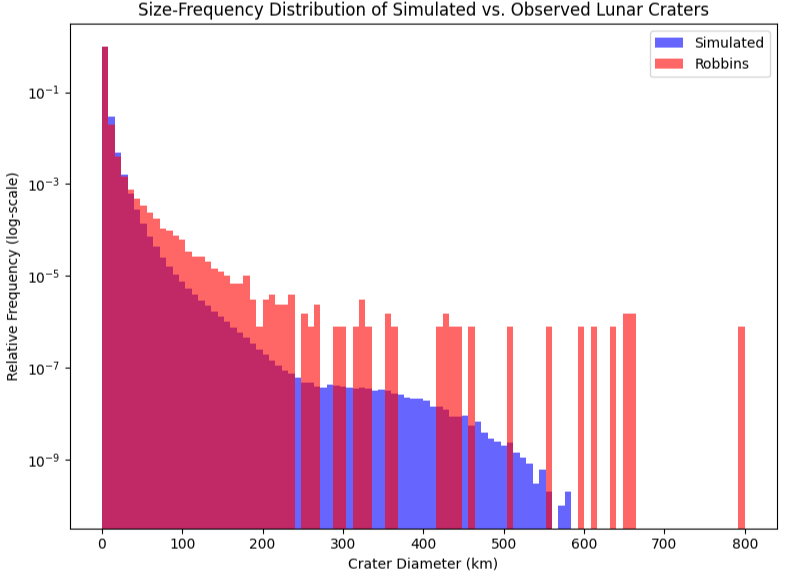

Fig 7. Normalized relative size frequency distribution comparing crater sizes on the moon and our simulated results. The actual craters are in blue, and the simulated craers are in red, with the darker red shade being the overlap between the two.

## Results
As seen in Fig. 7, the simulated craters were able to account for craters with diameters ≤ 150km on the Moon, but as crater diameter increases, the frequencies begin to diverge significantly. The overall shape of both distributions is similar, but the simulated NEO crater distribution experiences a steeper decrease in relative frequency as crater diameter increases since the NEOMOD simulation is limited to NEOs <100 km in diameter, it only rarely predicts impact craters > 600km.



In order to statistically determine if there is a difference between the two distributions, we ran a Kolmogorov-Smirnov (KS) test and a Mann-Whitney U test. We chose these two tests because the Mann Whitney U test compares medians and overall differences in frequencies while the KS test compares shape and spread of distribution, so we can draw a better conclusion that takes into account all properties of the distribtuions. For the Mann-Whitney U test, we established a null hypothesis that there is no difference between the SFD of simulated NEO impact craters and the SFD of existing lunar craters. We observed a p-value of 0.747 which is greater than our significance value of .05 and thus fail to reject the null hypothesis, suggesting that there is not enough evidence to conclude that the lunar crater distribution is statistically different from predicted distribution of NEO impacts. For the KS test, we established a null hypothesis that the population of lunar craters comes from the SFD of simulated impact craters. The KS test returned a p-value of $6.28 \times 10^{-5}$ when comparing the entirety of both distributions which wa much smaller than our significance value of 0.05, indicating that we should reject the null hypothesis. However upon closer analysis, the KS test returns a p-value > 0.05 up until a diameter of 172 km, suggesting that there is insufficient evidence to conclude the distributions are significantly different in shape or spread for that range. Meanwhile, the p-value drastically decreases after that diameter size, suggesting that there is conclusive evidence to reject the null hypothesis.

In [ ]:
# Run KS test
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(rel_freq_robbins, rel_freq_simulated)
print("p-value KS test:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: distributions differ significantly.")
else:
    print("Accept the null hypothesis: no significant difference detected.")

# Run Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(rel_freq_robbins, rel_freq_simulated)
print("p-value Mann-Whitney U test:", p_value)

if p_value < alpha:
    print("Reject the null hypothesis: distributions differ significantly.")
else:
    print("Accept the null hypothesis: no significant difference detected.")

p-value KS test: 6.281176788972264e-05
Reject the null hypothesis: distributions differ significantly.
p-value Mann-Whitney U test: 0.7467520570908502
Accept the null hypothesis: no significant difference detected.


In [ ]:
# KS test for upto 172km
stat, p_value = ks_2samp(rel_freq_robbins[0:21], rel_freq_simulated[0:21])
print("p-value KS test <172km:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: distributions differ significantly.")
else:
    print("Accept the null hypothesis: no significant difference detected.")

p-value KS test <172km: 0.09481656218610322
Accept the null hypothesis: no significant difference detected.


We believe the KS test rejects the null while the Mann Whitney U test fails to reject because the Mann Whitney U test compares medians and overall differences in frequencies while the KS test compares shape and spread of distribution. Since both distributions are heavily skewed to the right and match well up to a diameter of 172 km, their medians were also found to not be significantly different under the Mann Whitney U test. However, the KS test more heavily relies on comparing the overall distribution shape and spread, and due to the limitations of the NEOMOD simulation mentioned earlier as well as a sharply decreasing probability for predicting larger craters, it becomes harder for the NEO distribution to accurately predict larger craters, causing the test to fail. This becomes very apparent in Fig 6 where the size of error bars exponentially increases right around a crater diameter of 172 km for the NEO distribution, correlating with where the KS test null hypothesis also begins to fail (p < 0.05), suggesting that the NEOMOD simulation is insufficient for consistent predictions of larger impact crater sizes.

## Conclusion
According to the statistical tests used to compare the lunar and NEO SFDs described above, we conclude there is insufficient evidence that the distribution of predicted impact craters produced by NEOs is significantly different from lunar craters on the moon, suggesting that all craters under 172km can be accounted for by NEOs. Further analysis on more developed simulation or databases for NEOs should be conducted to gather more conclusive evidence on a correlation between NEO impact craters with diameters > 172km and lunar craters with diameters > 172km. Our work is consistent with the work produced by Werner (2002) who also found a strong correlation between the two distributions. Since the Earth and the Moon are exposed to the same flux of impactors, we can also conclude that the majority of impactors on Earth will also be from NEOs and therefore we should focus more on the threat of NEOs colliding with Earth rather than more distant asteroids from the asteroid belt or the outer solar system.

## Bibliography

Al-Sharadqah, A., & Chernov, N. 2009, Electron J Stat, 3, https://projecteuclid.org/journals/electronic-journal-of-statistics/volume-3/issue-none/Error-analysis-for-circle-fitting-algorithms/10.1214/09-EJS419.full. doi: 10.1214/09-EJS419


Britt, D. T., Yeomans, D., Housen, K., & Consolmagno, G., in Asteroids III, 485.  doi: 10.2307/j.ctv1v7zdn4


Davison, T. M., & Collins, G. S. 2022, Geophys Res Lett, 49, e2022GL101117. doi: 10.1029/2022GL101117


Huber, M. S., Kovaleva, E., Rae, A. S. P., Tisato, N., & Gulick, S. P. S. 2023, J Geophys Res Planets, 128, e2022JE007721. doi: 10.1029/2022JE007721


Ivanov, B. A. 2001, in Chronology and Evolution of Mars, ed. R. Kallenbach, J. Geiss, & W. K. Hartmann, Vol. 12 (Dordrecht: Springer Netherlands), 87, http://link.springer.com/10.1007/978-94-017-1035-0_4. doi: 10.1007/978-94-017-1035-0_4


Ivanov, B. A., Neukum, G., Bottke, W. F., et al. 2002, in Asteroids III (University of Arizona Press), 89, http://www.jstor.org/stable/10.2307/j.ctv1v7zdn4. doi: 10.2307/j.ctv1v7zdn4


Nesvorny, D., Deienno, R., Bottke, W. F., et al. 2023, Astron J, 166, 55. doi: 10.3847/1538-3881/ace040


Robbins, S. J., Riggs, J. D., Weaver, B. P., et al. 2018, Meteorit Planet Sci, 53 (John Wiley & Sons, Ltd), 891. doi: 10.1111/maps.12990


Salotti, J.-M. 2022, Futures, 138, 102933. doi: 10.1016/j.futures.2022.102933


Schmidt, R. M., & Housen, K. R. 1987, Int J Impact Eng, 5, 543. doi: 10.1016/0734-743X(87)90069-8


Werner, S. 2002, Icarus, 156, 287. doi: 10.1006/icar.2001.6789


Yue, Z., Johnson, B. C., Minton, D. A., et al. 2013, Nature Geosci, 6, 435. doi: 10.1038/ngeo1828
